# Анализ и обучение моделей прогнозирования цен

**Автор:** Горячевская Екатерина Николевна  
**Тема ВКР:** «Анализ и прогнозирование ценообразования на образовательные услуги»

[![Открыть в Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kathrin-23/muiv_costs/blob/main/ml/train_model.ipynb)

Ноутбук последовательно показывает загрузку данных, очистку, исследовательский анализ,
разбиение на обучающую/валидационную/тестовую выборки, подбор гиперпараметров,
кросс-валидацию, сравнение трех алгоритмов, диагностику и сохранение результатов.

## 1. Подтверждение среды Google Colab

Ячейка явно определяет Colab. Сохраненный результат ниже получен при контрольном
локальном выполнении; при запуске кнопкой **Open in Colab** значение изменится на `True`.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
print(f"Запуск в Google Colab: {IN_COLAB}")
print("Среда подтверждена: Google Colab" if IN_COLAB else "Среда контрольного выполнения: локальное ядро Python")

Запуск в Google Colab: False
Среда контрольного выполнения: локальное ядро Python


## 2. Зависимости и воспроизводимость

In [2]:
if IN_COLAB:
    %pip install -q pandas numpy scikit-learn joblib matplotlib openpyxl
else:
    print("Зависимости установлены в локальном виртуальном окружении проекта.")

Зависимости установлены в локальном виртуальном окружении проекта.


In [3]:
import json
import warnings
from datetime import datetime
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
print("Версии:", {"pandas": pd.__version__, "scikit-learn": __import__("sklearn").__version__})

Версии: {'pandas': '2.2.2', 'scikit-learn': '1.5.1'}


## 3. Загрузка набора по URL

В Google Colab набор всегда загружается из репозитория. При контрольном выполнении
используется идентичный локальный файл, если он доступен.

In [4]:
DATASET_URL = "https://raw.githubusercontent.com/Kathrin-23/muiv_costs/main/data/processed/prepared_dataset.csv"
LOCAL_DATASET = Path("data/processed/prepared_dataset.csv")

if IN_COLAB or not LOCAL_DATASET.exists():
    data = pd.read_csv(DATASET_URL)
    execution_source = DATASET_URL
else:
    data = pd.read_csv(LOCAL_DATASET)
    execution_source = str(LOCAL_DATASET)

print("URL набора:", DATASET_URL)
print("Источник текущего выполнения:", execution_source)
print("Размер исходной таблицы:", data.shape)
display(data.head())

URL набора: https://raw.githubusercontent.com/Kathrin-23/muiv_costs/main/data/processed/prepared_dataset.csv
Источник текущего выполнения: data/processed/prepared_dataset.csv
Размер исходной таблицы: (691, 14)


,year,region,education_level,program_name,study_format,duration_months,base_price,competitor_price,demand_index,salary_index,advertising_spend,discount_percent,student_count,final_price
0,2017,Москва,магистратура,"24.04.08 Магистр Инженер-патентовед, по направ...",очная,24,141750.0,141750.0,20.0,100.00,0.0,0.0,124,145000.0
1,2017,Москва,магистратура,"24.04.08 Магистр Инженер-патентовед, по направ...",очная,24,141750.0,141750.0,20.0,100.00,0.0,0.0,124,52000.0
2,2022,Москва,магистратура,27.04.08 Управление интеллектуальной собственн...,очная,24,197000.0,197000.0,20.0,134.85,0.0,0.0,124,238254.8
3,2023,Москва,магистратура,27.04.08 Управление интеллектуальной собственн...,очная,24,238254.8,197000.0,20.0,142.76,0.0,0.0,124,238254.8
4,2024,Москва,магистратура,27.04.08 Управление интеллектуальной собственн...,очная,24,238254.8,197000.0,20.0,154.80,0.0,0.0,124,238254.8


## 4. Очистка и проверка качества данных

In [5]:
FEATURE_COLUMNS = [
    "year", "region", "education_level", "program_name", "study_format",
    "duration_months", "base_price", "competitor_price", "demand_index",
    "salary_index", "advertising_spend", "discount_percent", "student_count",
]
TARGET_COLUMN = "final_price"
CATEGORICAL_COLUMNS = ["region", "education_level", "program_name", "study_format"]
NUMERIC_COLUMNS = [column for column in FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS]
REQUIRED_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

clean = data.copy()
clean.columns = [str(column).replace("\ufeff", "").strip() for column in clean.columns]
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(clean.columns))
if missing_columns:
    raise ValueError(f"Отсутствуют обязательные столбцы: {missing_columns}")

duplicates_before = int(clean.duplicated().sum())
for column in NUMERIC_COLUMNS + [TARGET_COLUMN]:
    clean[column] = pd.to_numeric(clean[column], errors="coerce")
for column in CATEGORICAL_COLUMNS:
    clean[column] = clean[column].fillna("не указано").astype(str).str.strip()
missing_before = int(clean[REQUIRED_COLUMNS].isna().sum().sum())
clean = clean.dropna(subset=NUMERIC_COLUMNS + [TARGET_COLUMN]).drop_duplicates()
clean = clean[REQUIRED_COLUMNS].reset_index(drop=True)

quality = pd.DataFrame({
    "Показатель": ["Строк до очистки", "Дубликатов удалено", "Пропусков до очистки", "Строк после очистки"],
    "Значение": [len(data), duplicates_before, missing_before, len(clean)],
})
display(quality)
assert not clean.empty and clean.isna().sum().sum() == 0

,Показатель,Значение
0,Строк до очистки,691
1,Дубликатов удалено,0
2,Пропусков до очистки,0
3,Строк после очистки,691


## 5. Исследовательский анализ

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,691.0,NaN,NaN,NaN,2021.905933,2.277453,2017.0,2022.0,2023.0,2024.0,2024.0
region,691,1,Москва,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,691,4,дополнительное образование,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
program_name,691,178,"38.03.02 Менеджмент, профиль Управление интелл...",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_format,691,5,очная,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,691.0,NaN,NaN,NaN,18.824891,17.32644,6.0,6.0,6.0,24.0,48.0
base_price,691.0,NaN,NaN,NaN,80931.135166,81545.567784,4000.0,15000.0,60000.0,127500.0,370000.0
competitor_price,691.0,NaN,NaN,NaN,71058.248915,70450.424905,6500.0,15000.0,20000.0,120000.0,243600.0
demand_index,691.0,NaN,NaN,NaN,33.535355,26.747625,20.0,20.0,20.0,38.08,100.0
salary_index,691.0,NaN,NaN,NaN,135.144356,18.066735,100.0,134.85,142.76,154.8,154.8


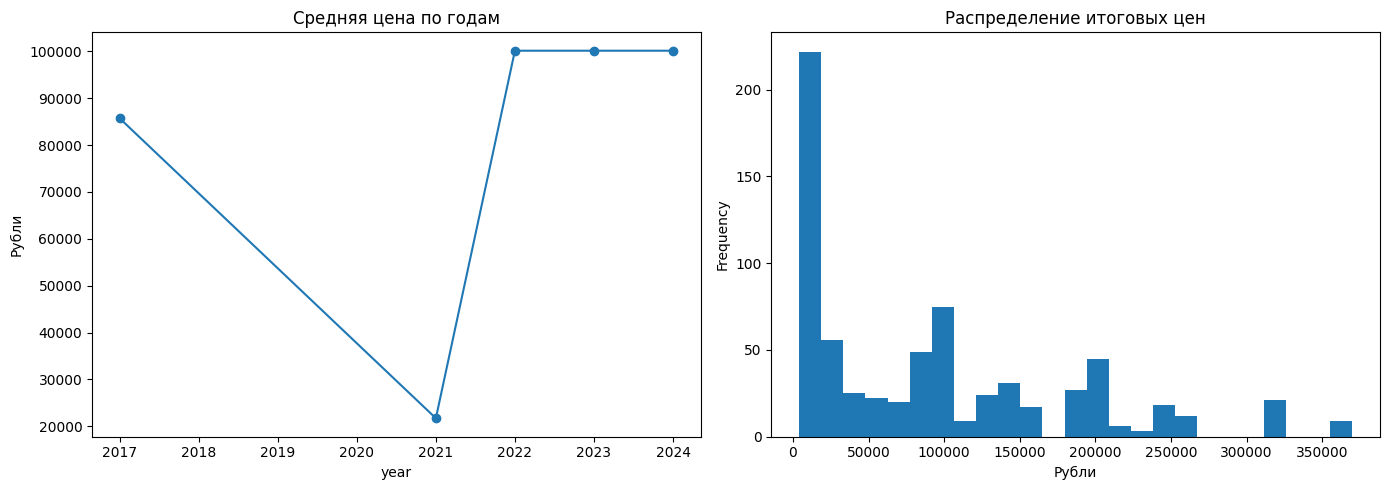

,education_level,наблюдений,средняя_цена
1,высшее образование,70,163160.285714
3,магистратура,119,137135.835294
0,бакалавриат,90,121243.857778
2,дополнительное образование,412,59033.009709


In [6]:
display(clean.describe(include="all").T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clean.groupby("year")["final_price"].mean().plot(marker="o", ax=axes[0], title="Средняя цена по годам")
axes[0].set_ylabel("Рубли")
clean["final_price"].plot(kind="hist", bins=25, ax=axes[1], title="Распределение итоговых цен")
axes[1].set_xlabel("Рубли")
plt.tight_layout()
plt.show()

display(
    clean.groupby("education_level", as_index=False)
    .agg(наблюдений=("final_price", "size"), средняя_цена=("final_price", "mean"))
    .sort_values("средняя_цена", ascending=False)
)

## 6. Разбиение train / validation / test

In [7]:
X = clean[FEATURE_COLUMNS]
y = clean[TARGET_COLUMN]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)
splits = {
    "train": (X_train, y_train),
    "validation": (X_validation, y_validation),
    "test": (X_test, y_test),
}
split_table = pd.DataFrame(
    [{"Выборка": name, "Строк": len(values[0]), "Доля": round(len(values[0]) / len(clean), 3)}
     for name, values in splits.items()]
)
display(split_table)

,Выборка,Строк,Доля
0,train,483,0.699
1,validation,104,0.151
2,test,104,0.151


## 7. Конвейеры и сетки гиперпараметров

In [8]:
def make_preprocessor():
    return ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLUMNS),
        ("numeric", StandardScaler(), NUMERIC_COLUMNS),
    ])

estimators = {
    "random_forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "ridge": Ridge(),
}
display_names = {
    "random_forest": "Случайный лес",
    "gradient_boosting": "Градиентный бустинг",
    "ridge": "Ridge",
}
parameter_grids = {
    "random_forest": {
        "regressor__n_estimators": [100, 180],
        "regressor__max_depth": [8, None],
        "regressor__min_samples_leaf": [1, 3],
    },
    "gradient_boosting": {
        "regressor__n_estimators": [100, 180],
        "regressor__learning_rate": [0.05, 0.1],
        "regressor__max_depth": [2, 3],
    },
    "ridge": {"regressor__alpha": [0.1, 1.0, 10.0, 100.0]},
}
print("Будут сравнены:", ", ".join(display_names.values()))

Будут сравнены: Случайный лес, Градиентный бустинг, Ridge


## 8. Обучение, GridSearchCV, метрики и кросс-валидация

In [9]:
def metrics(y_true, y_pred):
    return {
        "mae": round(float(mean_absolute_error(y_true, y_pred)), 2),
        "rmse": round(float(root_mean_squared_error(y_true, y_pred)), 2),
        "mape": round(float(mean_absolute_percentage_error(y_true, y_pred)), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
    }

models = {}
reports = {}
comparison_rows = []
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, estimator in estimators.items():
    started = perf_counter()
    pipeline = Pipeline([("preprocessor", make_preprocessor()), ("regressor", estimator)])
    search = GridSearchCV(
        pipeline,
        parameter_grids[model_name],
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    evaluation_model = search.best_estimator_
    split_metrics = {
        split_name: metrics(y_values, evaluation_model.predict(X_values))
        for split_name, (X_values, y_values) in splits.items()
    }
    cv_scores = cross_validate(
        evaluation_model,
        X_train,
        y_train,
        cv=cv,
        scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1,
    )
    cv_report = {
        "folds": 5,
        "mae_mean": round(float(-cv_scores["test_mae"].mean()), 2),
        "mae_std": round(float(cv_scores["test_mae"].std()), 2),
        "rmse_mean": round(float(-cv_scores["test_rmse"].mean()), 2),
        "r2_mean": round(float(cv_scores["test_r2"].mean()), 4),
    }
    X_final = pd.concat([X_train, X_validation])
    y_final = pd.concat([y_train, y_validation])
    final_model = clone(evaluation_model).fit(X_final, y_final)
    models[model_name] = final_model
    best_params = {key.replace("regressor__", ""): value for key, value in search.best_params_.items()}
    duration = round(perf_counter() - started, 3)
    train_rmse = split_metrics["train"]["rmse"]
    validation_rmse = split_metrics["validation"]["rmse"]
    overfitting = (
        split_metrics["train"]["r2"] - split_metrics["validation"]["r2"] > 0.15
        or validation_rmse / train_rmse > 1.5
    )
    reports[model_name] = {
        "display_name": display_names[model_name],
        "best_params": best_params,
        "metrics": split_metrics,
        "cross_validation": cv_report,
        "duration_seconds": duration,
        "overfitting": overfitting,
    }
    for split_name, values in split_metrics.items():
        comparison_rows.append({
            "model_name": model_name,
            "Модель": display_names[model_name],
            "Выборка": split_name,
            **values,
            "CV MAE": cv_report["mae_mean"],
            "Время, сек.": duration,
        })
    print(f"{display_names[model_name]}: готово за {duration} сек.; параметры {best_params}")

Случайный лес: готово за 3.594 сек.; параметры {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 180}


Градиентный бустинг: готово за 0.441 сек.; параметры {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 180}
Ridge: готово за 0.069 сек.; параметры {'alpha': 0.1}


## 9. Сравнительная таблица и выбор итоговой модели

In [10]:
comparison = pd.DataFrame(comparison_rows)
display(comparison)

selected_model = min(
    reports,
    key=lambda name: reports[name]["metrics"]["validation"]["rmse"],
)
print("Итоговая модель:", display_names[selected_model])
print("Критерий: минимальный RMSE на валидационной выборке")
display(pd.DataFrame([
    {
        "Модель": display_names[name],
        "Validation RMSE": report["metrics"]["validation"]["rmse"],
        "Test RMSE": report["metrics"]["test"]["rmse"],
        "Test R²": report["metrics"]["test"]["r2"],
        "CV MAE": report["cross_validation"]["mae_mean"],
    }
    for name, report in reports.items()
]).sort_values("Validation RMSE"))

,model_name,Модель,Выборка,mae,rmse,mape,r2,CV MAE,"Время, сек."
0,random_forest,Случайный лес,train,10345.32,19422.84,0.5051,0.9538,15305.20,3.594
1,random_forest,Случайный лес,validation,16288.24,43255.33,0.4319,0.7408,15305.20,3.594
2,random_forest,Случайный лес,test,16155.32,42768.16,0.5009,0.7741,15305.20,3.594
3,gradient_boosting,Градиентный бустинг,train,9903.14,16245.22,0.4075,0.9677,16915.05,0.441
4,gradient_boosting,Градиентный бустинг,validation,16160.91,36354.00,0.3994,0.8169,16915.05,0.441
5,gradient_boosting,Градиентный бустинг,test,14894.92,35060.06,0.3594,0.8482,16915.05,0.441
6,ridge,Ridge,train,8990.68,16342.05,0.2050,0.9673,16662.39,0.069
7,ridge,Ridge,validation,15472.76,25561.46,0.4719,0.9095,16662.39,0.069
8,ridge,Ridge,test,13825.62,22196.23,0.2691,0.9391,16662.39,0.069


Итоговая модель: Ridge
Критерий: минимальный RMSE на валидационной выборке


,Модель,Validation RMSE,Test RMSE,Test R²,CV MAE
2,Ridge,25561.46,22196.23,0.9391,16662.39
1,Градиентный бустинг,36354.00,35060.06,0.8482,16915.05
0,Случайный лес,43255.33,42768.16,0.7741,15305.20


## 10. Диагностика качества итоговой модели

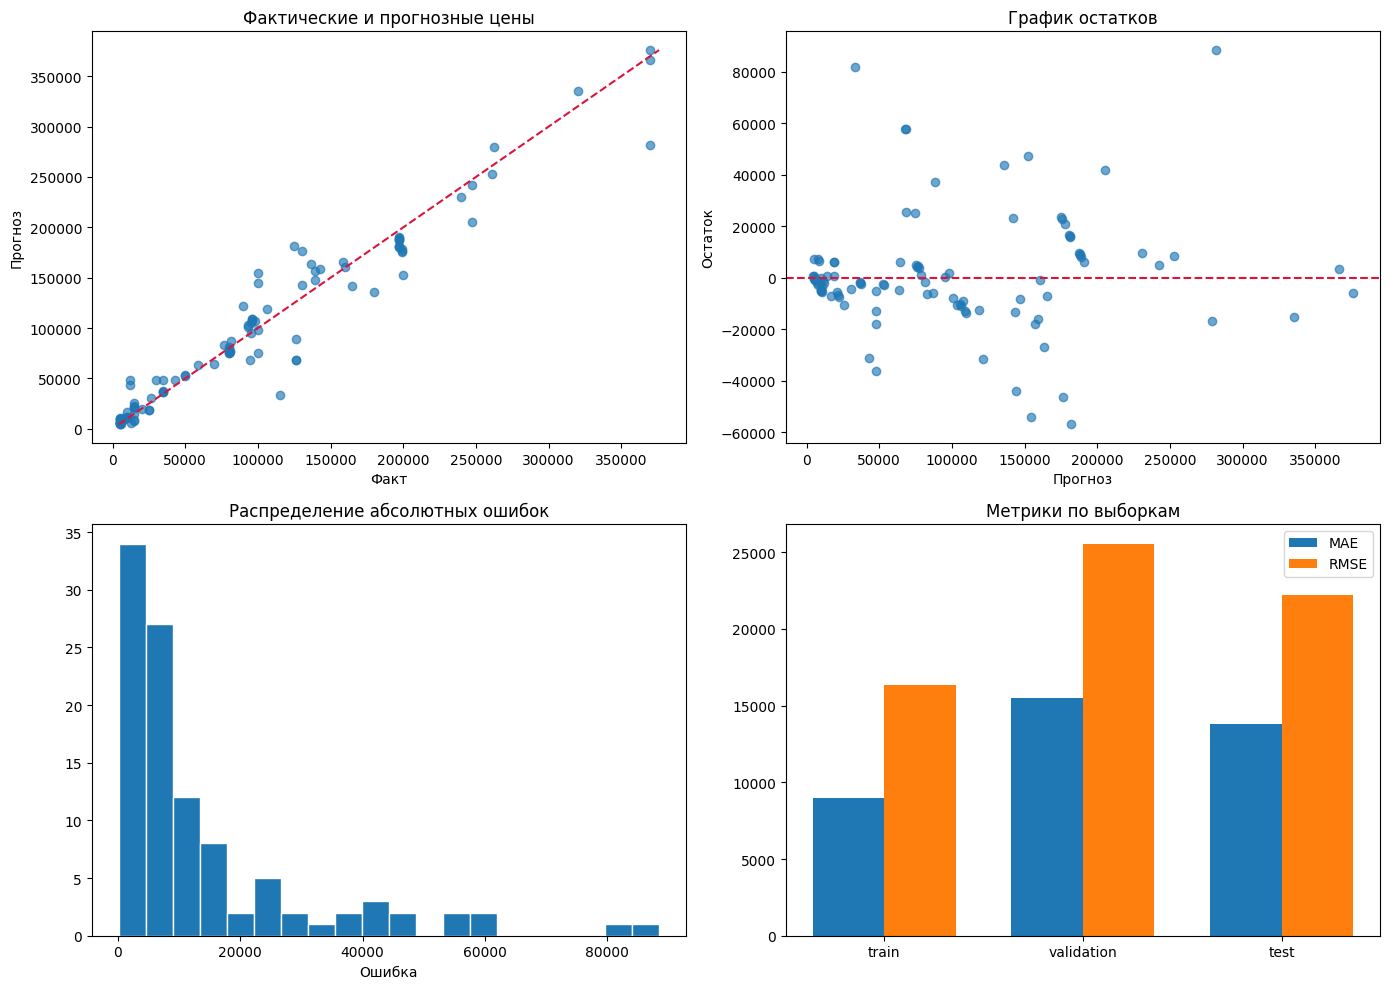

Вывод: есть признаки переобучения; следует контролировать разрыв метрик.


In [11]:
best_model = models[selected_model]
evaluation_pipeline = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("regressor", clone(estimators[selected_model])),
])
evaluation_pipeline.set_params(**{
    f"regressor__{key}": value for key, value in reports[selected_model]["best_params"].items()
})
evaluation_pipeline.fit(X_train, y_train)
test_predictions = evaluation_pipeline.predict(X_test)
residuals = np.asarray(y_test) - test_predictions

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(y_test, test_predictions, alpha=0.65)
bounds = [min(y_test.min(), test_predictions.min()), max(y_test.max(), test_predictions.max())]
axes[0, 0].plot(bounds, bounds, "--", color="crimson")
axes[0, 0].set(title="Фактические и прогнозные цены", xlabel="Факт", ylabel="Прогноз")
axes[0, 1].scatter(test_predictions, residuals, alpha=0.65)
axes[0, 1].axhline(0, linestyle="--", color="crimson")
axes[0, 1].set(title="График остатков", xlabel="Прогноз", ylabel="Остаток")
axes[1, 0].hist(np.abs(residuals), bins=20, edgecolor="white")
axes[1, 0].set(title="Распределение абсолютных ошибок", xlabel="Ошибка")
split_names = ["train", "validation", "test"]
axes[1, 1].bar(
    np.arange(3) - 0.18,
    [reports[selected_model]["metrics"][name]["mae"] for name in split_names],
    0.36,
    label="MAE",
)
axes[1, 1].bar(
    np.arange(3) + 0.18,
    [reports[selected_model]["metrics"][name]["rmse"] for name in split_names],
    0.36,
    label="RMSE",
)
axes[1, 1].set_xticks(np.arange(3), ["train", "validation", "test"])
axes[1, 1].set_title("Метрики по выборкам")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

if reports[selected_model]["overfitting"]:
    print("Вывод: есть признаки переобучения; следует контролировать разрыв метрик.")
else:
    print("Вывод: выраженных признаков переобучения не обнаружено.")

## 11. Важность признаков

,Признак,Важность
142,categorical__program_name_Программа профессион...,254831.089997
141,categorical__program_name_Программа профессион...,245289.860719
143,categorical__program_name_Программа профессион...,237836.610110
114,categorical__program_name_Программа повышения ...,198247.136021
135,categorical__program_name_Программа профессион...,197860.610711
144,categorical__program_name_Программа профессион...,197860.610711
134,categorical__program_name_Программа профессион...,197860.610711
111,categorical__program_name_Программа повышения ...,193039.131847
59,categorical__program_name_Научное консультиров...,120372.710020
139,categorical__program_name_Программа профессион...,108866.106940


/var/folders/5w/rh6rdn8x507b6wz6pl7fdxgc0000gn/T/ipykernel_94400/3580592604.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


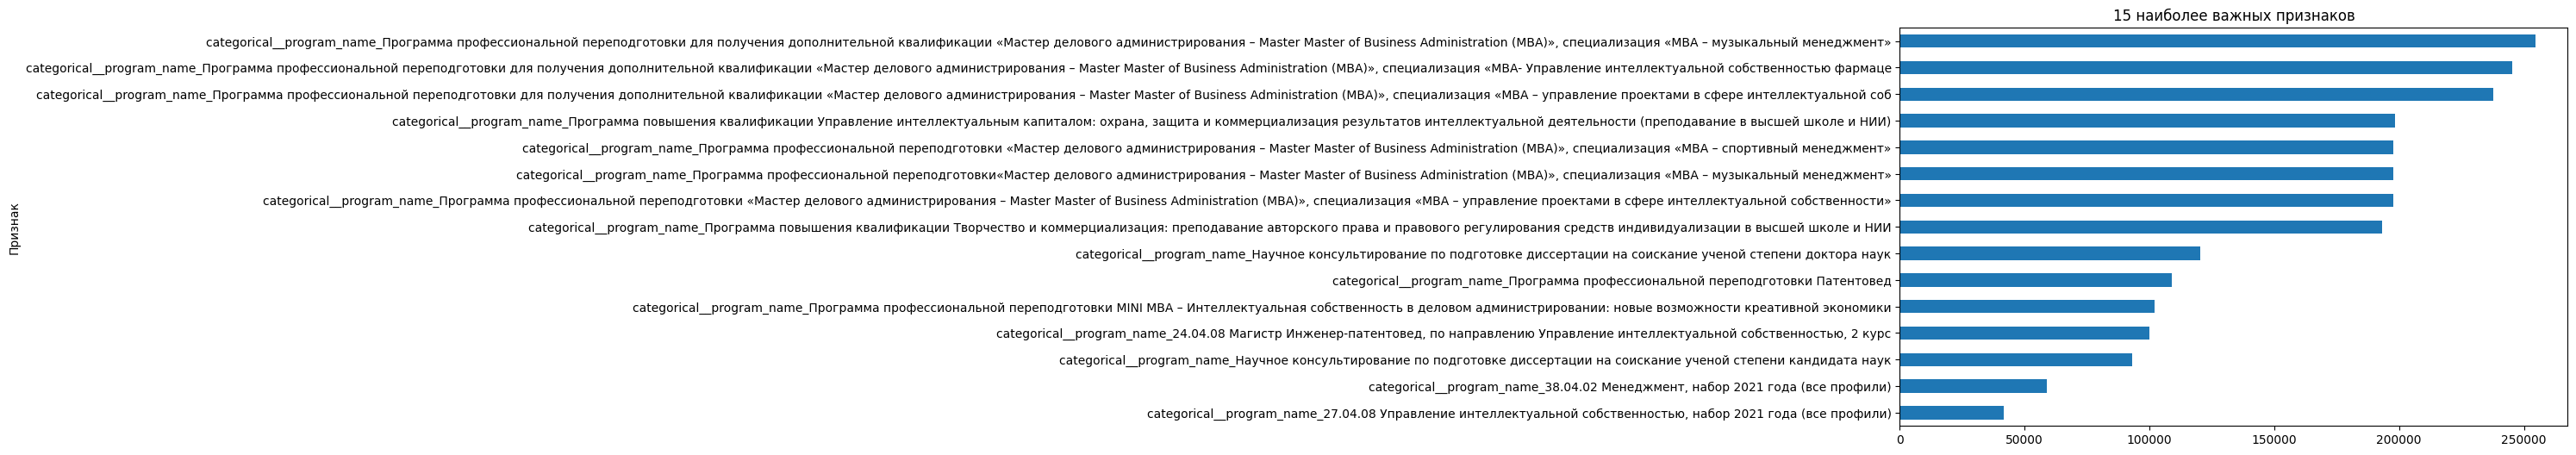

In [12]:
preprocessor = evaluation_pipeline.named_steps["preprocessor"]
regressor = evaluation_pipeline.named_steps["regressor"]
feature_names = preprocessor.get_feature_names_out()
if hasattr(regressor, "feature_importances_"):
    importance_values = regressor.feature_importances_
else:
    importance_values = np.abs(np.ravel(regressor.coef_))
importance = (
    pd.DataFrame({"Признак": feature_names, "Важность": importance_values})
    .sort_values("Важность", ascending=False)
    .head(15)
)
display(importance)
importance.sort_values("Важность").plot.barh(
    x="Признак", y="Важность", figsize=(10, 6), legend=False, title="15 наиболее важных признаков"
)
plt.tight_layout()
plt.show()

## 12. Сохранение моделей, метрик и реестра

In [13]:
OUTPUT_DIR = Path("colab_results")
OUTPUT_DIR.mkdir(exist_ok=True)
model_filenames = {
    "random_forest": "model_random_forest.pkl",
    "gradient_boosting": "model_gradient_boosting.pkl",
    "ridge": "model_ridge.pkl",
}
for name, model in models.items():
    joblib.dump(model, OUTPUT_DIR / model_filenames[name])
    (OUTPUT_DIR / f"metrics_{name}.json").write_text(
        json.dumps(reports[name], ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

registry = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "selected_model": selected_model,
    "selection_metric": "validation.rmse",
    "models": reports,
}
(OUTPUT_DIR / "model_registry.json").write_text(
    json.dumps(registry, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")

saved_files = sorted(path.name for path in OUTPUT_DIR.iterdir())
print("Сохранено файлов:", len(saved_files))
print("\n".join(saved_files))

Сохранено файлов: 8
metrics_gradient_boosting.json
metrics_random_forest.json
metrics_ridge.json
model_comparison.csv
model_gradient_boosting.pkl
model_random_forest.pkl
model_registry.json
model_ridge.pkl


## Итог

Ноутбук подтверждает полный эксперимент: данные загружены по URL, очищены и
проанализированы; три модели настроены и оценены одинаковым способом; тестовая
выборка не использовалась при выборе алгоритма; каждая модель и ее метрики
сохранены отдельно, а итоговый выбор зафиксирован в реестре.